# Boosting Transfer Learning with Task-Specific Weights

## Loading data

In [1]:
import pandas as pd
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=100, slice_=None, resize=1.0, color=True)
faces.image = faces.images[:, 60:188, 60:188]
faces.data = faces.images.reshape(
    faces.images.shape[0],
    faces.images.shape[1] * faces.images.shape[2],
    faces.images.shape[3],
)

class_count = len(faces.target_names)

print(faces.target_names)
print(faces.images.shape)

['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
(1140, 250, 250, 3)


In [2]:
import numpy as np

mask = np.zeros(faces.target.shape, dtype=bool)

for target in np.unique(faces.target):
    mask[np.where(faces.target == target)[0][:100]] = 1

X_faces = faces.data[mask]
y_faces = faces.target[mask]
X_faces = np.reshape(
    X_faces,
    (
        X_faces.shape[0],
        faces.images.shape[1],
        faces.images.shape[2],
        faces.images.shape[3],
    ),
)
X_faces.shape

(500, 250, 250, 3)

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input

face_images = preprocess_input(np.array(X_faces * 255))

X_train, X_test, y_train, y_test = train_test_split(
    face_images, y_faces, train_size=0.8, stratify=y_faces, random_state=0
)

In [4]:
from tensorflow.keras.layers import Dense, Flatten, Resizing
from tensorflow.keras.models import Sequential, load_model

base_model = load_model("Data/vggface.h5")
base_model.trainable = False

model = Sequential()
model.add(Resizing(224, 224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(class_count, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [5]:
hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), batch_size=10, epochs=10
)

Epoch 1/10
40/40 [==============================] - 9s 205ms/step - loss: 1.0764 - accuracy: 0.8525 - val_loss: 0.1305 - val_accuracy: 0.9500
Epoch 2/10
40/40 [==============================] - 8s 199ms/step - loss: 0.0468 - accuracy: 0.9825 - val_loss: 0.1762 - val_accuracy: 0.9500
Epoch 3/10
40/40 [==============================] - 8s 201ms/step - loss: 0.0115 - accuracy: 0.9950 - val_loss: 0.1342 - val_accuracy: 0.9700
Epoch 4/10
40/40 [==============================] - 8s 207ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.1052 - val_accuracy: 0.9700
Epoch 5/10
40/40 [==============================] - 8s 209ms/step - loss: 7.9661e-04 - accuracy: 1.0000 - val_loss: 0.1025 - val_accuracy: 0.9700
Epoch 6/10
40/40 [==============================] - 8s 205ms/step - loss: 2.4368e-04 - accuracy: 1.0000 - val_loss: 0.0993 - val_accuracy: 0.9600
Epoch 7/10
40/40 [==============================] - 8s 204ms/step - loss: 1.9836e-04 - accuracy: 1.0000 - val_loss: 0.0989 - val_accuracy: 0

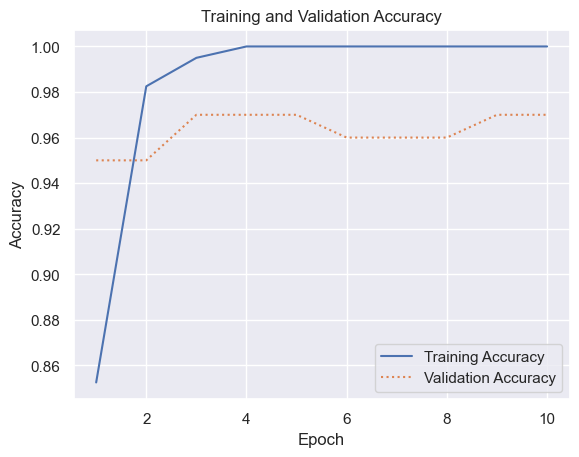

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

4/4 [==============================] - 2s 350ms/step


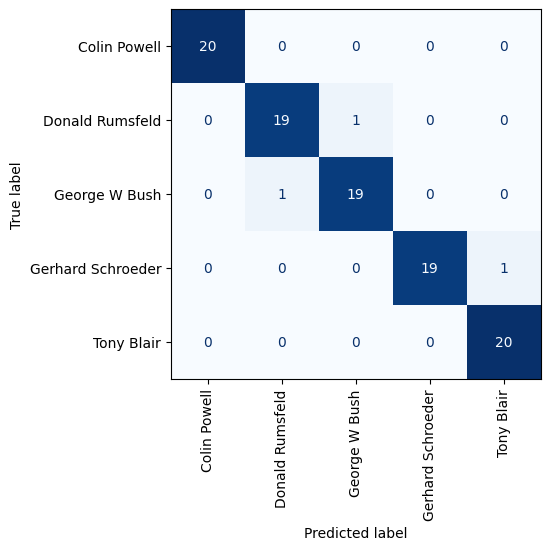

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

sns.reset_orig()

y_pred = model.predict(X_test)
fig, ax = plt.subplots()
ax.grid(False)

cmd.from_predictions(
    y_test,
    y_pred.argmax(axis=1),
    display_labels=faces.target_names,
    colorbar=False,
    cmap="Blues",
    xticks_rotation="vertical",
    ax=ax,
)
plt.show();